In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
training_file_path = "/content/drive/MyDrive/Colab Notebooks/data-mining-cse572/flood-prediction-project/train.csv"

In [ ]:
df = pd.read_csv(training_file_path)

## EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null 

In [ ]:
df.shape

(1117957, 22)

In [ ]:
df.isnull().sum()

,0
id,0
MonsoonIntensity,0
TopographyDrainage,0
RiverManagement,0
Deforestation,0
Urbanization,0
ClimateChange,0
DamsQuality,0
Siltation,0
AgriculturalPractices,0


In [ ]:
df['FloodProbability'].describe()

,FloodProbability
count,1.117957e+06
mean,5.044803e-01
std,5.102610e-02
min,2.850000e-01
25%,4.700000e-01
50%,5.050000e-01
75%,5.400000e-01
max,7.250000e-01


<Axes: >

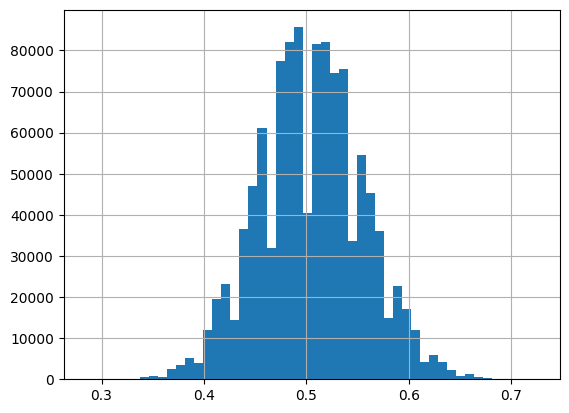

In [ ]:
df['FloodProbability'].hist(bins=50)

In [ ]:
df.corr()['FloodProbability'].sort_values(ascending=False)

,FloodProbability
FloodProbability,1.000000
DeterioratingInfrastructure,0.190007
MonsoonIntensity,0.189098
DamsQuality,0.187996
TopographyDrainage,0.187635
RiverManagement,0.187131
Siltation,0.186789
PopulationScore,0.185890
Landslides,0.185346
ClimateChange,0.184761


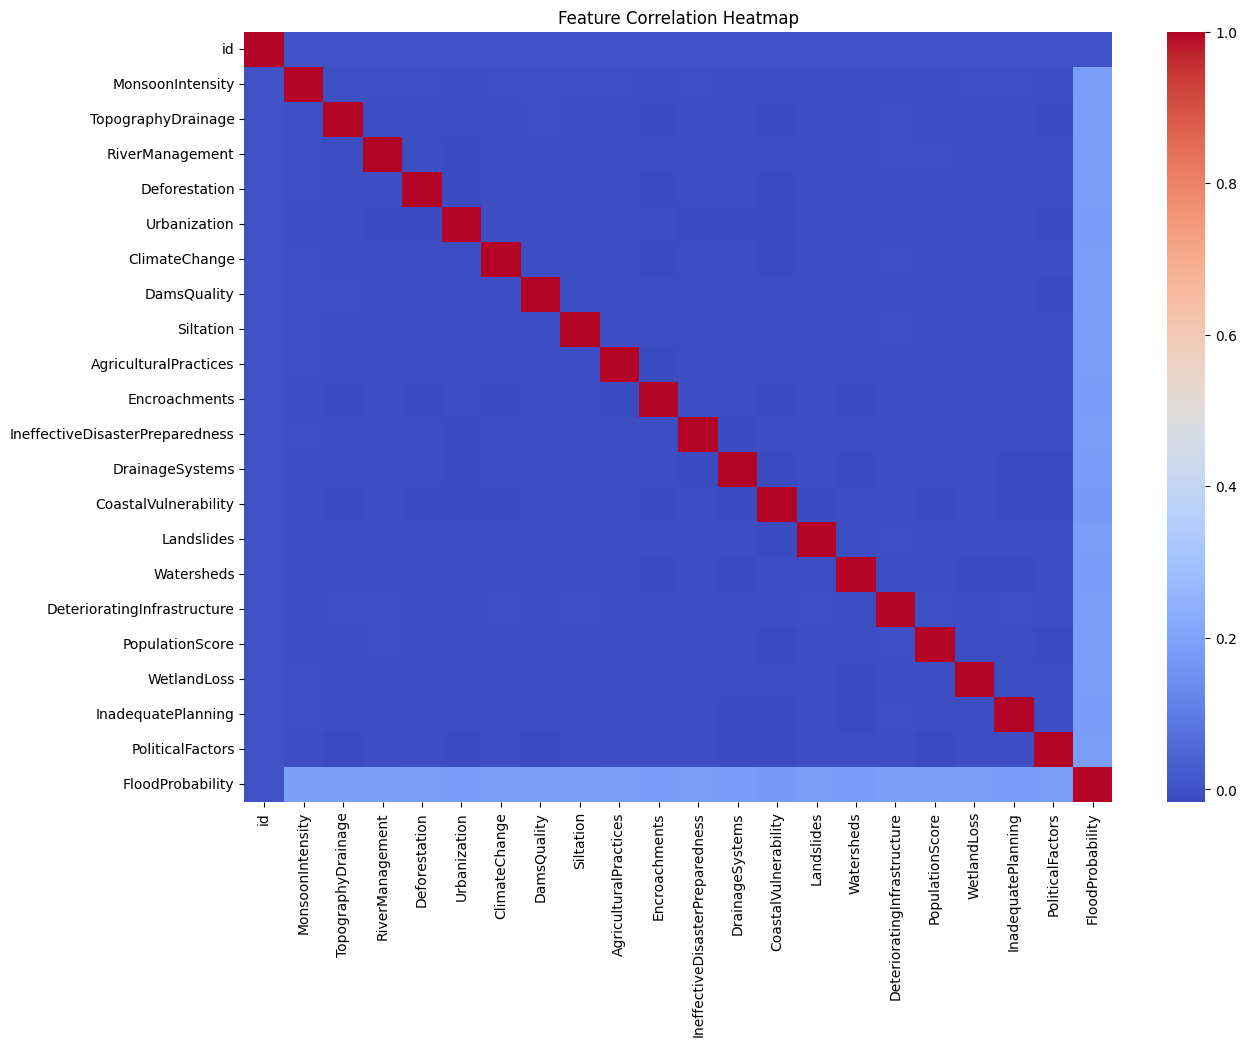

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
df.groupby('Urbanization')['FloodProbability'].mean().head(10)

,FloodProbability
Urbanization,
0,0.480398
1,0.484252
2,0.489027
3,0.495831
4,0.500773
5,0.505807
6,0.510197
7,0.515289
8,0.515069


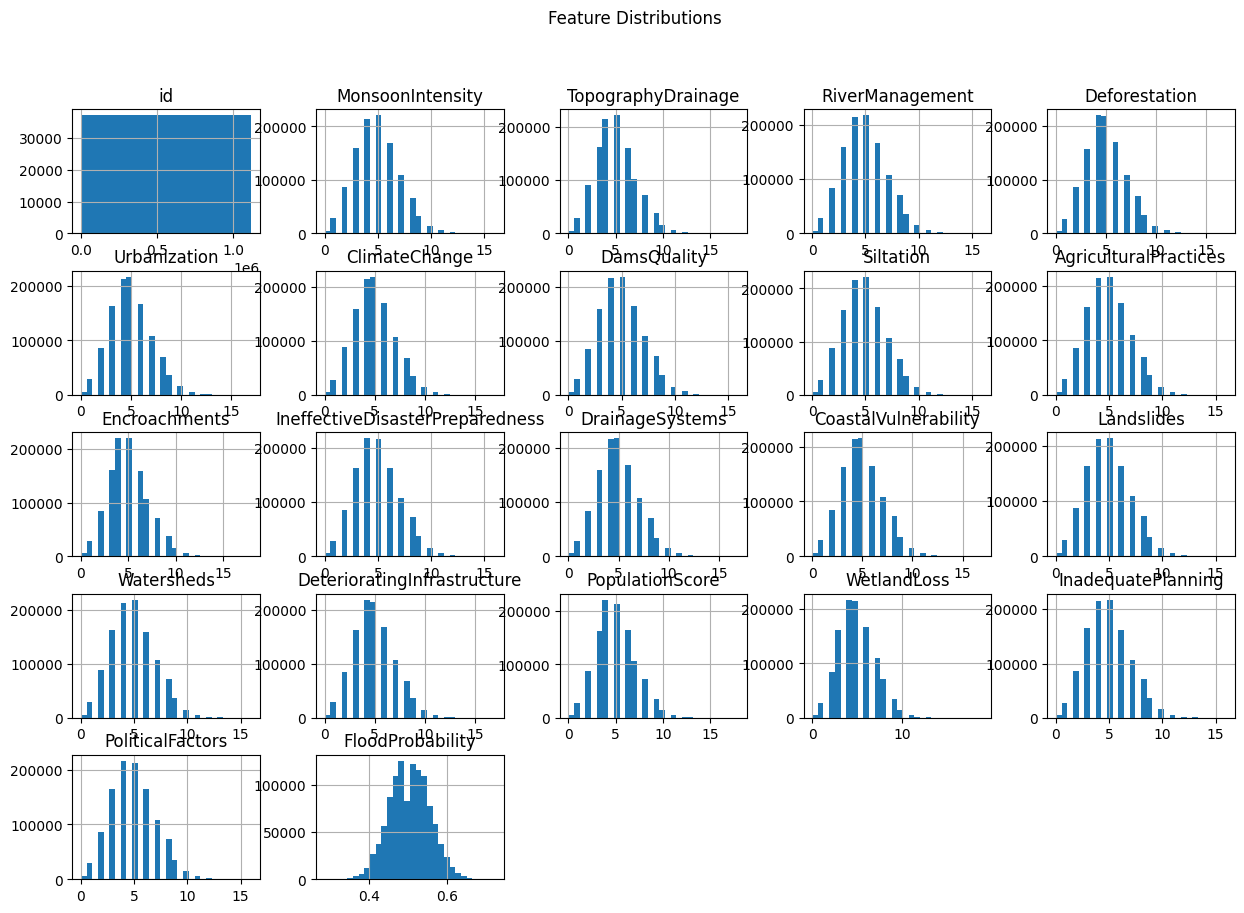

In [ ]:
num_cols = df.select_dtypes('number').columns
df[num_cols].hist(bins=30, figsize=(15,10))
plt.suptitle('Feature Distributions')
plt.show()

<Axes: >

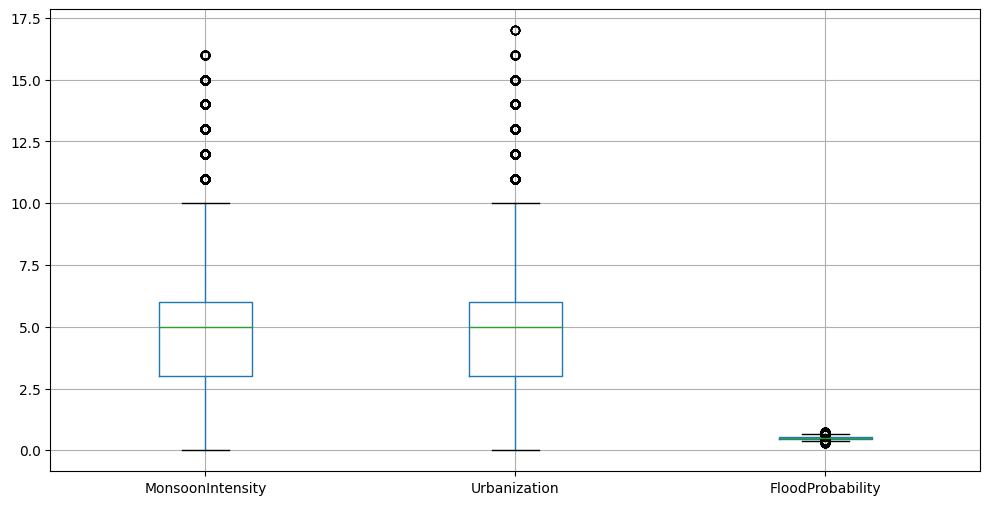

In [ ]:
df.boxplot(column=['MonsoonIntensity', 'Urbanization', 'FloodProbability'], figsize=(12,6))

##MODEL DEVELOPMENT

### CLASSIFICATION

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)

In [ ]:
# --------- (Optional) fast run on huge dataset ----------
FAST_MODE = False            # set True for quick iterations
FAST_N = 200_000             # sample size if FAST_MODE

df_ = df.copy()
if FAST_MODE and len(df_) > FAST_N:
    df_ = df_.sample(FAST_N, random_state=42)

In [ ]:
# --------- Features/Target ----------
FEATURES = [c for c in df_.columns if c not in ["id", "FloodProbability"]]
X = df_[FEATURES]
y = (df_["FloodProbability"] >= 0.5).astype(int)   # binary label @0.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

num_cols = list(X_train.select_dtypes(include=[np.number]).columns)

In [ ]:
# --------- Pipelines ----------
scale_num = ColumnTransformer([("num", StandardScaler(with_mean=False), num_cols)], remainder="drop")

logreg = Pipeline([
    ("prep", scale_num),
    ("clf", LogisticRegression(max_iter=200, n_jobs=-1, class_weight="balanced", solver="saga"))
])

rf = Pipeline([
    ("prep", "passthrough"),
    ("clf", RandomForestClassifier(
        n_estimators=200, n_jobs=-1, class_weight="balanced_subsample", random_state=42
    ))
])

models = {"LogisticRegression": logreg, "RandomForest": rf}

In [ ]:
def evaluate(name, pipe, X_train, y_train, X_test, y_test):
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)  # fixed 0.5 for now (simple & consistent)

    # --- Metrics
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"\n{name} — Metrics")
    print(f"ROC-AUC: {auc:.4f} | Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

    # --- ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, lw=2); plt.plot([0,1],[0,1], "--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"{name} — ROC (AUC={auc:.3f})")
    plt.tight_layout(); plt.show()

    # --- Precision–Recall curve
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(rec, prec, lw=2)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{name} — Precision–Recall")
    plt.tight_layout(); plt.show()

    # --- Confusion Matrix
    plt.figure(figsize=(4.2,3.6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name} — Confusion Matrix @0.5"); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    return {"model": name, "roc_auc": auc, "accuracy": acc, "f1": f1}


LogisticRegression — Metrics
ROC-AUC: 0.9250 | Accuracy: 0.8473 | F1: 0.8572

Classification report:
               precision    recall  f1-score   support

           0     0.8166    0.8563    0.8360    101616
           1     0.8752    0.8398    0.8572    121976

    accuracy                         0.8473    223592
   macro avg     0.8459    0.8481    0.8466    223592
weighted avg     0.8486    0.8473    0.8475    223592



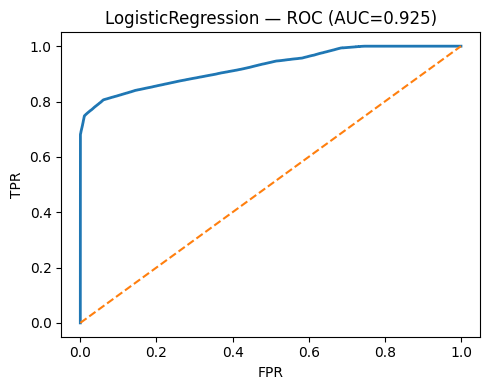

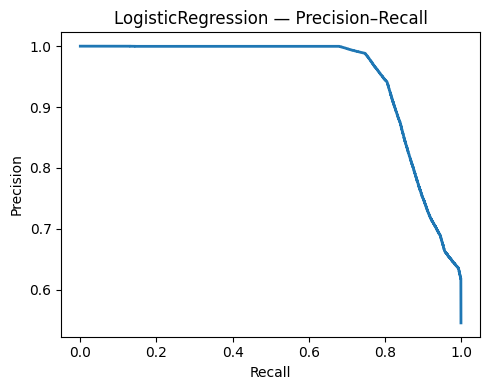

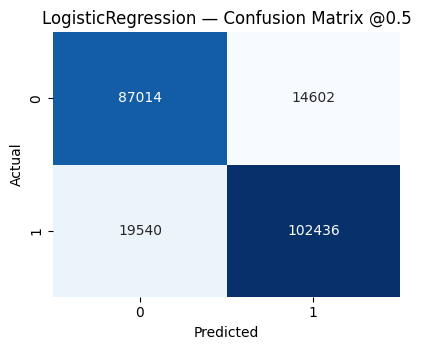


RandomForest — Metrics
ROC-AUC: 0.8959 | Accuracy: 0.8060 | F1: 0.8232

Classification report:
               precision    recall  f1-score   support

           0     0.7903    0.7802    0.7852    101616
           1     0.8188    0.8276    0.8232    121976

    accuracy                         0.8060    223592
   macro avg     0.8046    0.8039    0.8042    223592
weighted avg     0.8059    0.8060    0.8059    223592



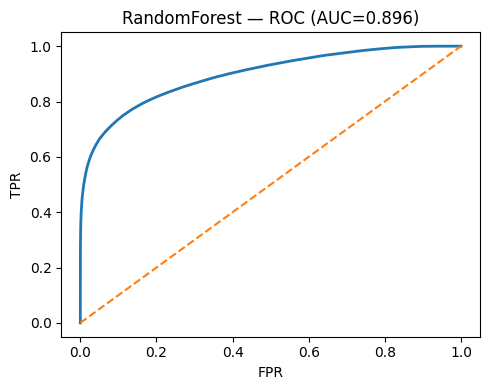

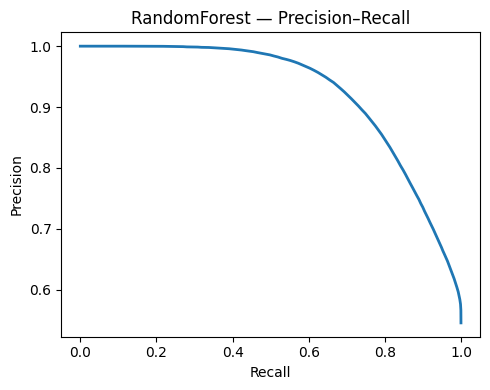

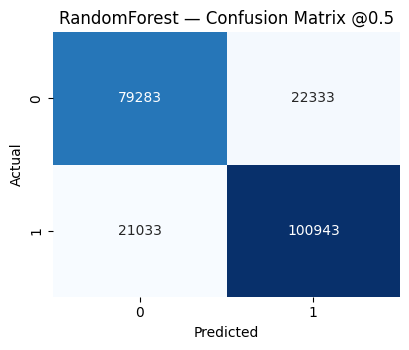

,model,roc_auc,accuracy,f1
0,LogisticRegression,0.925033,0.847302,0.857155
1,RandomForest,0.895878,0.806049,0.823178


In [ ]:
results = [evaluate(n, m, X_train, y_train, X_test, y_test) for n,m in models.items()]
pd.DataFrame(results).sort_values("roc_auc", ascending=False)

### REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd

In [ ]:
# Features / target
X = df.drop(columns=["id", "FloodProbability"])
y = df["FloodProbability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Models
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"{name}: R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")
    results.append({"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae})

results_df = pd.DataFrame(results)
display(results_df)

LinearRegression: R²=0.8449 | RMSE=0.0201 | MAE=0.0158
DecisionTree: R²=0.0568 | RMSE=0.0495 | MAE=0.0394
RandomForest: R²=0.6584 | RMSE=0.0298 | MAE=0.0244


,Model,R2,RMSE,MAE
0,LinearRegression,0.844877,0.020080,0.015792
1,DecisionTree,0.056798,0.049514,0.039405
2,RandomForest,0.658401,0.029798,0.024376


from matplotlib import pyplot as plt
results_df['R2'].plot(kind='hist', bins=20, title='R2')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
results_df['RMSE'].plot(kind='hist', bins=20, title='RMSE')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
results_df['MAE'].plot(kind='hist', bins=20, title='MAE')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='R2', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='RMSE', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='MAE', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Load test CSV (no FloodProbability column) ===
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data-mining-cse572/flood-prediction-project/test.csv")

# Keep same feature columns as training
X_test_final = test_df.drop(columns=["id"])

# === 2. Pick your best trained model (e.g., Linear Regression) ===
best_model = models["LinearRegression"]   # or "RandomForest" etc.

# === 3. Predict FloodProbability for test set ===
y_pred_final = best_model.predict(X_test_final)

# === 4. Create DataFrame of predictions ===
submission = pd.DataFrame({
    "id": test_df["id"],
    "PredictedFloodProbability": y_pred_final
})

# === 5. Save predictions to CSV (optional for submission/final use) ===
submission.to_csv("flood_predictions_checkpoint1.csv", index=False)
print("✅ Predictions saved to flood_predictions_checkpoint1.csv")
print(submission.head())

✅ Predictions saved to flood_predictions_checkpoint1.csv
        id  PredictedFloodProbability
0  1117957                   0.573613
1  1117958                   0.455271
2  1117959                   0.454752
3  1117960                   0.466179
4  1117961                   0.466085


count    745305.000000
mean          0.504534
std           0.046893
min           0.302409
25%           0.477030
50%           0.500000
75%           0.534104
max           0.759971
Name: PredictedFloodProbability, dtype: float64


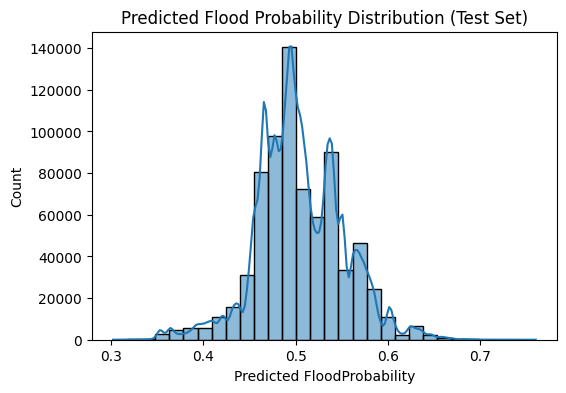

In [ ]:
# --- Basic stats ---
print(submission["PredictedFloodProbability"].describe())

# --- Distribution plot ---
plt.figure(figsize=(6,4))
sns.histplot(submission["PredictedFloodProbability"], bins=30, kde=True)
plt.title("Predicted Flood Probability Distribution (Test Set)")
plt.xlabel("Predicted FloodProbability")
plt.ylabel("Count")
plt.show()
